In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics
import glob

In [2]:
# parameters used for the simulation
r_tot = 70774597466.3827
r_bot = 0.4 * r_tot
r_top = 0.9 * r_tot
Nr = 570
Ntheta = 360
Nphi = 720
dr_grid = (r_top - r_bot) / Nr
r_env_init = 5.149819426617924E+10

In [3]:
PATTERN= "/z2/users/cj517/lscaledir_3D/r_min0.4_r_max0.9_from2d_v0_Om0/zerodir/*"
all_files = sorted(glob.glob(PATTERN))
all_files

[]

In [4]:
file = all_files[0]
file

IndexError: list index out of range

In [5]:
def read_file(fname):
    with open(fname, 'r') as f:
        t = float(f.readline())
        df = pd.read_csv(f, sep='\s+',
                    #names=["num_theta", "theta_deg", "HP1", "r1", "renv", "HP2", "r21", "rcore"])
        #names=["num_theta", "theta_deg", "HP1", "r1", "renv", "HP2", "r21", "rcore", "renvdown", "renvup", "rcoredown", "rcoreup"])
        names=["num_phi", "phi_deg", "num_theta", "theta_deg", "HP1", "r1", "r2","r3","r4","r5", "HP2", "r21", "r22","r23","r24","r25"])
        df["time"] = t
        return df

In [6]:
all_data = pd.DataFrame(read_file(file))
all_data = all_data.set_index(["num_theta"]).sort_index()
all_data

,num_phi,phi_deg,theta_deg,HP1,r1,r2,r3,r4,r5,HP2,r21,r22,r23,r24,r25,time
num_theta,,,,,,,,,,,,,,,,
1,710,236.5,30.2,5.615973e+09,5.144499e+10,5.144499e+10,5.144499e+10,5.144499e+10,5.144499e+10,0.0,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,19999820.0
1,38,12.5,30.2,5.615998e+09,5.130456e+10,5.130456e+10,5.130456e+10,5.130456e+10,5.130456e+10,0.0,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,19999820.0
1,37,12.2,30.2,5.615999e+09,5.130456e+10,5.130456e+10,5.130456e+10,5.130456e+10,5.130456e+10,0.0,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,19999820.0
1,708,235.8,30.2,5.615977e+09,5.137477e+10,5.137477e+10,5.137477e+10,5.137477e+10,5.137477e+10,0.0,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,19999820.0
1,275,91.5,30.2,5.615995e+09,5.130456e+10,5.137477e+10,5.130456e+10,5.137477e+10,5.137477e+10,0.0,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,19999820.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,355,118.2,149.8,5.615981e+09,5.130456e+10,5.144499e+10,5.130456e+10,5.144499e+10,5.144499e+10,0.0,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,19999820.0
360,716,238.5,149.8,5.615963e+09,5.116414e+10,5.130456e+10,5.116414e+10,5.130456e+10,5.130456e+10,0.0,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,19999820.0
360,350,116.5,149.8,5.615986e+09,5.123435e+10,5.137477e+10,5.123435e+10,5.137477e+10,5.137477e+10,0.0,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,19999820.0


In [23]:
df_slice = all_data[all_data['num_phi'] == 1]
df_slice

,num_phi,phi_deg,theta_deg,HP1,r1,r2,r3,r4,r5,HP2,r21,r22,r23,r24,r25,time,depth
num_theta,,,,,,,,,,,,,,,,,
1,1,0.2,30.2,5.615967e+09,5.144499e+10,5.144499e+10,5.144499e+10,5.144499e+10,5.144499e+10,0.0,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,19999820.0,0.000752
2,1,0.2,30.5,5.615969e+09,5.144499e+10,5.144499e+10,5.144499e+10,5.144499e+10,5.144499e+10,0.0,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,19999820.0,0.000752
3,1,0.2,30.8,5.615972e+09,5.144499e+10,5.144499e+10,5.144499e+10,5.144499e+10,5.144499e+10,0.0,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,19999820.0,0.000752
4,1,0.2,31.2,5.615975e+09,5.144499e+10,5.144499e+10,5.144499e+10,5.144499e+10,5.144499e+10,0.0,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,19999820.0,0.000752
5,1,0.2,31.5,5.615978e+09,5.144499e+10,5.144499e+10,5.144499e+10,5.144499e+10,5.144499e+10,0.0,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,19999820.0,0.000752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
356,1,0.2,148.5,5.615987e+09,5.123435e+10,5.123435e+10,5.123435e+10,5.123435e+10,5.123435e+10,0.0,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,19999820.0,0.003728
357,1,0.2,148.8,5.615978e+09,5.130456e+10,5.130456e+10,5.130456e+10,5.130456e+10,5.130456e+10,0.0,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,19999820.0,0.002736
358,1,0.2,149.2,5.615970e+09,5.130456e+10,5.130456e+10,5.130456e+10,5.130456e+10,5.130456e+10,0.0,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,2.841516e+10,19999820.0,0.002736


In [25]:
all_data['depth'] = (r_env_init - all_data['r1']) / r_tot

In [26]:
Hp_conv = df_slice['HP1'].mean()

Text(0, 0.5, 'Penetration depth [$H_p$]')

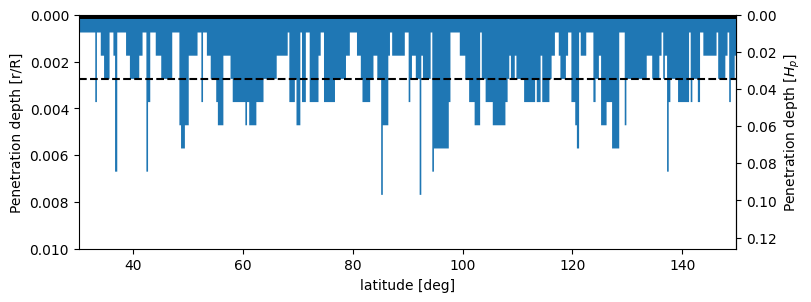

In [27]:
plt.rc("figure", figsize=(8, 8/2.75))
plt.rc("figure", dpi=100)
fig, ax = plt.subplots(layout='constrained')
ax.step(df_slice['theta_deg'], df_slice['depth'], where='post', label='Step plot', alpha=0)
ax.fill_between(df_slice['theta_deg'], df_slice['depth'], step='post', alpha=1)
ax.set_ylim(0,0.01)
ax.set_xlim(df_slice['theta_deg'].min(),df_slice['theta_deg'].max())
fig.gca().invert_yaxis()
ax.axhline(y=0,color='k',linewidth=5)
ax.axhline(y=df_slice['depth'].mean(),color='k',linestyle='--')



ax.set_xlabel(r'latitude [deg]')
ax.set_ylabel(r'Penetration depth [r/R]')
def P2R(P):
    return P * Hp_conv / r_tot

def R2P(R):
    return R * r_tot / Hp_conv

secax = ax.secondary_yaxis('right', functions=(R2P, P2R))
secax.set_ylabel(r'Penetration depth [$H_p$]')

# fig.savefig('angularsnapshot.svg')

In [29]:
depth_slice = df_slice['r1'].values

In [11]:
import cj_plotter
from music_scripts.musicdata import MusicData

In [12]:
sim = MusicData('z2_data/r_min0.4_r_max0.9_from2d_v0_Om0/params_sample.nml')

In [13]:
r = sim[2000].grid.r_grid.cell_points()
t = sim[2000].grid.theta_grid.cell_points()

In [14]:
vel_1 = sim[2000].field['vel_1'].array()[:,:,0]

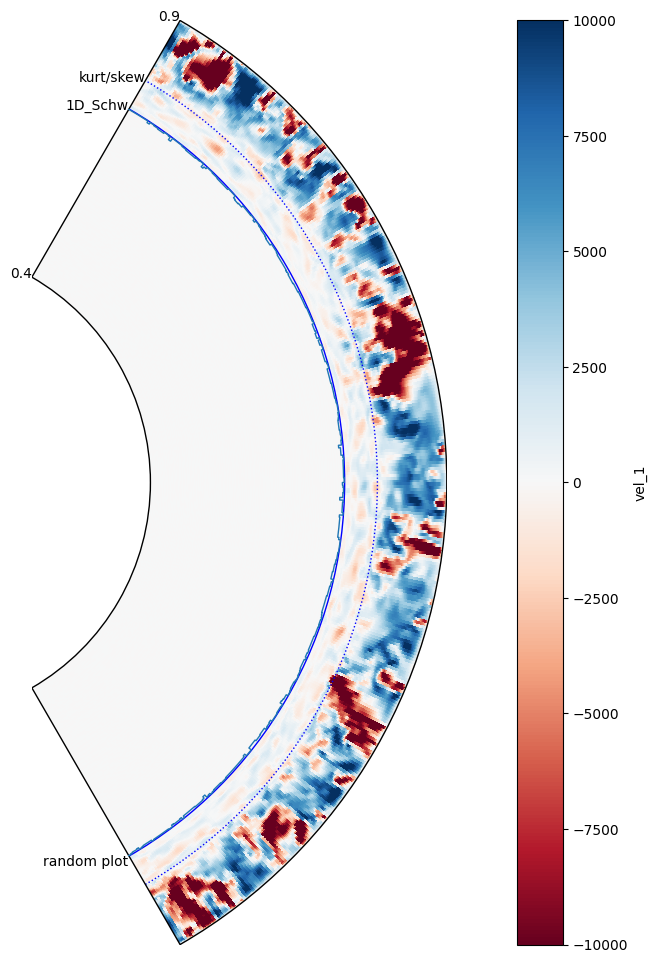

In [36]:
example_plot = cj_plotter.plot2D(t, r/r_tot, vel_1, -1e4, 1e4, cmap='RdBu') # , visible_ax=False)

example_plot.add_arc(5.149819426617924E+10/r_tot, edgecolor='blue', label='1D_Schw')
example_plot.add_arc(55412016190.5/r_tot, edgecolor='blue', linestyle=':', label='kurt/skew')
example_plot.colorbar(label='vel_1')

n = 360
r_test = np.random.uniform(5.149819426617924E+10/r_tot - 0.02, 5.149819426617924E+10/r_tot, size=n)
t_test = np.linspace(np.radians(30), np.radians(150), n)
example_plot.step(np.radians(df_slice['theta_deg'].values), depth_slice / r_tot, linestyle='-', label='random plot', label_position='bottom')

